# 📊 Employee Attrition & Performance Analysis

---

## 🎯 Objective
To analyze employee data and identify factors affecting attrition.

---

## ❗ Problem Statement
Employee attrition leads to higher cost and productivity loss.  
The goal is to understand and predict employee attrition.

---

## 📊 Insights
- Low income employees leave more  
- Some departments have higher attrition  
- Experience impacts employee retention  

---

## 📚 Libraries Used

- pandas → data handling  
- numpy → numerical operations  
- matplotlib → basic visualization  
- seaborn → advanced visualization  
- sklearn → machine learning & evaluation  

---

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## 📊 Dataset Features

- Id → Employee id
- Age → Employee age  
- Department → Department of employee (HR, Sales, IT, etc.)  
- JobRole → Employee job position  
- Gender → Male or Female  
- Attrition → Employee left (1) or not (0)  
- MonthlyIncome → Employee salary  
- PerformanceRating → Performance score  
- YearsAtCompany → Total years worked in company  

---

In [26]:
df = pd.read_csv("emp_attrition.csv")
df.head()

,id,Age,Department,JobRole,Gender,Attrition,MonthlyIncome,PerformanceRating,YearsAtCompany
0,0,NaN,Human Resource,Laboratory Technician,Male,0,2596,3,10
1,1,35.0,Sales,Sales Representative,NaN,0,2899,3,4
2,2,32.0,sales,Sales Executive,Male,0,4627,3,3
3,3,38.0,IT,Healthcare Representative,Female,0,5347,3,6
4,4,50.0,Research & Development,Manager,Female,1,19033,3,31


## 📊 Dataset Size

- Dataset contains employee records with multiple features  
- Used for analyzing employee attrition  

---

In [27]:
df.shape

(3147, 9)

## 📊 Data Structure

The dataset includes:

- 9 columns with a mix of numerical and categorical data  
- Numerical features (Age, Attrition, MonthlyIncome, PerformanceRating, YearsAtCompany)  
- Categorical features (Department, JobRole, Gender)  
- All columns are properly structured and ready for analysis  

➡️ Suitable for data analysis and machine learning tasks  

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3147 entries, 0 to 3146
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 3147 non-null   int64 
 1   Age                2911 non-null   object
 2   Department         3094 non-null   object
 3   JobRole            3147 non-null   object
 4   Gender             3069 non-null   object
 5   Attrition          3147 non-null   int64 
 6   MonthlyIncome      3147 non-null   int64 
 7   PerformanceRating  3147 non-null   int64 
 8   YearsAtCompany     3147 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 221.4+ KB


# 📊 Shows overall data distribution (count, mean, spread) → helps understand data structure  
# 📈 Identifies trends (% attrition), variation (↑↓ income), and tenure patterns

In [29]:
df.describe()

,id,Attrition,MonthlyIncome,PerformanceRating,YearsAtCompany
count,3147.000000,3147.000000,3147.000000,3147.000000,3147.000000
mean,925.286940,0.138862,6339.397521,3.139816,6.900858
std,550.325205,0.345858,4610.584686,0.346851,5.998015
min,0.000000,0.000000,1009.000000,3.000000,0.000000
25%,452.000000,0.000000,2888.000000,3.000000,3.000000
50%,914.000000,0.000000,4877.000000,3.000000,5.000000
75%,1379.000000,0.000000,7725.000000,3.000000,9.000000
max,2068.000000,1.000000,19999.000000,4.000000,41.000000


# 🧹 Detects missing values (nulls) across columns → highlights data quality issues  
# 🔁 Checks for duplicate records → ensures data consistency and avoids redundancy

In [30]:
df.isnull().sum()

id                     0
Age                  236
Department            53
JobRole                0
Gender                78
Attrition              0
MonthlyIncome          0
PerformanceRating      0
YearsAtCompany         0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df["MonthlyIncome"].unique()[:10]

array([ 2596,  2899,  4627,  5347, 19033,  4197,  1281,  3067,  6439,
        2741])

# 🔍 Displays unique Age values → detects inconsistencies (text, nulls)  
# 📊 Shows Age frequency (incl. nulls) → understands distribution & missing impact  
# ⚠️ Filters invalid entries (e.g., "yrs") → identifies data type issues for cleaning

In [33]:
df["Age"].unique()[:20]

array([nan, '35.0', '32.0', '38.0', '50.0', '27.0', '34.0', '40.0',
       '51.0', '25.0', '29.0', '48.0', '39.0', '33.0', '42.0', '30.0',
       '43.0', '29.0 yrs', '26.0', '24.0'], dtype=object)

In [34]:
df["Age"].value_counts(dropna=False).head(10)

Age
NaN     236
29.0    144
34.0    142
36.0    142
35.0    140
31.0    140
38.0    123
40.0    119
30.0    102
32.0    100
Name: count, dtype: int64

In [35]:
df[df["Age"].astype(str).str.contains("yrs", na=False)]

,id,Age,Department,JobRole,Gender,Attrition,MonthlyIncome,PerformanceRating,YearsAtCompany
25,25,29.0 yrs,Research & Development,Manufacturing Director,Female,0,4834,4,1
30,30,41.0 yrs,Research & Development,Healthcare Representative,Male,0,6142,3,5
31,31,34.0 yrs,Research & Development,Laboratory Technician,Male,0,4490,3,9
48,48,18.0 yrs,Research & Development,Laboratory Technician,Female,1,1611,3,0
67,67,43.0 yrs,Research & Development,Manager,Female,0,19436,3,20
...,...,...,...,...,...,...,...,...,...
3042,1928,29.0 yrs,Sales,Sales Representative,Male,1,1091,3,1
3050,1937,38.0 yrs,Research & Development,Research Scientist,Female,0,2133,3,20
3101,2008,35.0 yrs,Research & Development,Research Scientist,Male,0,5098,3,10
3124,2036,36.0 yrs,Sales,Sales Executive,Male,0,5406,4,15


# 🔍 Displays unique Gender values → detects inconsistencies (case, abbreviations, nulls)  
# 📊 Shows Gender frequency (incl. nulls) → understands distribution & imbalance  
# ⚠️ Filters inconsistent formats (e.g., male, M, fem) → identifies standardization issues for cleaning

In [36]:
df["Gender"].unique()

array(['Male', nan, 'Female', 'male', ' fem', 'M', 'MALE ', 'female', 'F'],
      dtype=object)

In [37]:
df["Gender"].value_counts(dropna=False)

Gender
Male      1654
Female    1021
M           80
NaN         78
 fem        66
F           63
female      63
male        62
MALE        60
Name: count, dtype: int64

In [38]:
df[df["Gender"].str.contains(" ", na=False)]

,id,Age,Department,JobRole,Gender,Attrition,MonthlyIncome,PerformanceRating,YearsAtCompany
17,17,NaN,Research & Development,Manufacturing Director,fem,0,7441,3,10
34,34,31.0,Human Resources,Human Resources,MALE,0,5745,3,10
54,54,34.0,Research & Development,Research Scientist,MALE,0,2132,3,1
66,66,29.0,Research & Development,Research Scientist,MALE,1,2496,3,1
94,94,43.0,hr,Laboratory Technician,MALE,0,1569,3,1
...,...,...,...,...,...,...,...,...,...
3049,1936,39.0,Research & Development,Manufacturing Director,fem,0,5151,4,10
3071,1966,32.0,Research & Development,Manufacturing Director,MALE,0,9679,4,1
3079,1974,31.0,sales,Laboratory Technician,MALE,0,1129,3,1
3139,2056,39.0,Sales,Sales Executive,fem,0,12031,3,20


## 🔍 Displays unique Department values → detects inconsistencies (case, spacing, duplicates)

In [39]:
df["Department"].unique()

array(['Human Resource', 'Sales', 'sales', 'IT', 'Research & Development',
       'it dept', 'Human Resources', 'Sales ', 'HR', nan, 'hr '],
      dtype=object)

## 📊 Data Visualization

# 📊 Shows distribution of numerical features → helps understand data spread and skewness  
# 📈 Identifies patterns (income range, tenure spread, attrition imbalance) → useful for analysis & insights

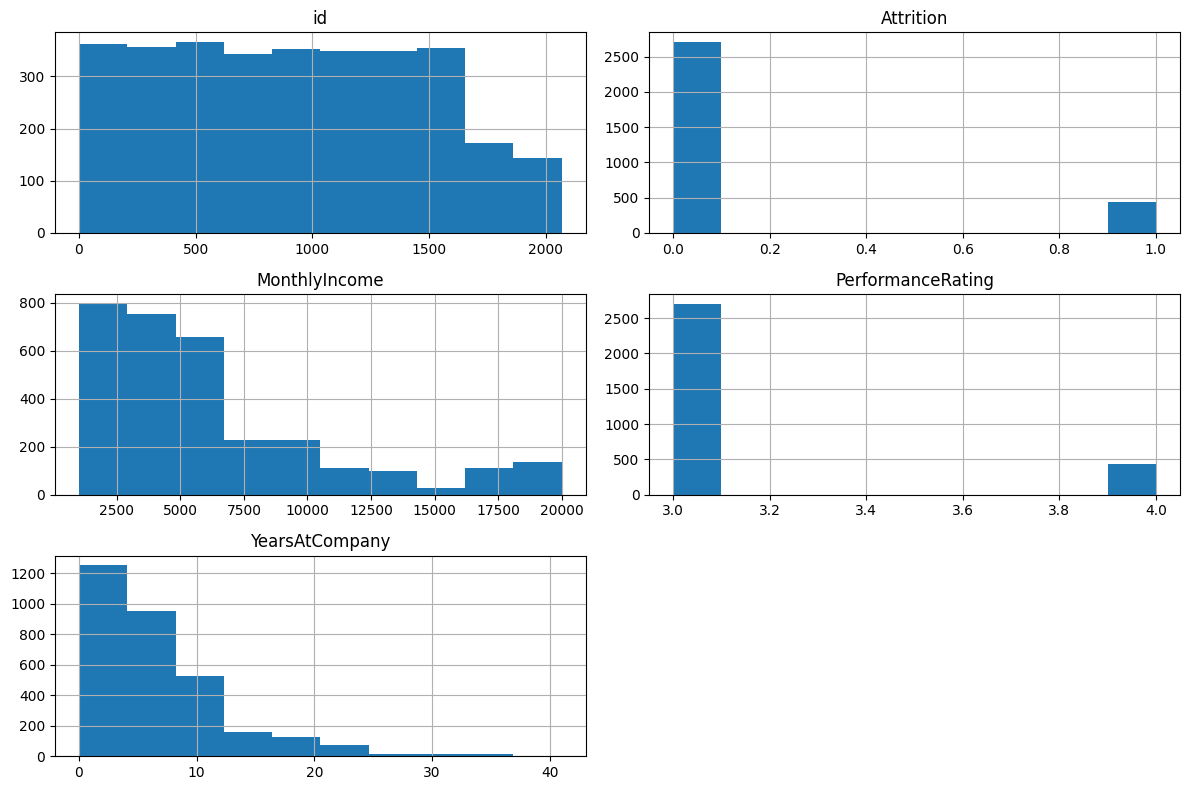

In [40]:

num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols].hist(bins=10, figsize=(12,8))
plt.tight_layout()   # overlap avoid karta hai
plt.show()

# 🧹 Missing Data Visualization (Heatmap)
# 📊 Highlights missing values pattern → helps identify which columns need data cleaning

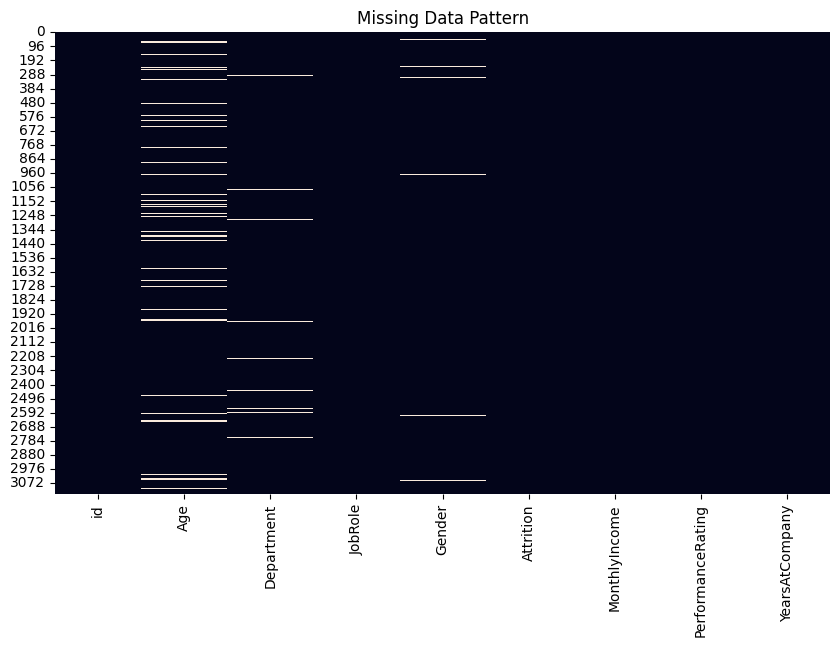

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

## 🧹 Data Cleaning

# 📁 Data Copy / Backup

In [42]:
df_clean = df.copy()

## 🧹 Age Data Cleaning


# 🔍 Removed text inconsistencies (e.g., "yrs") → ensured uniform numeric format  
# 🔄 Converted data type to numeric → handled invalid values using coercion  
# 🩹 Filled missing values using median → maintained data balance without skew  
# ✅ Converted final values to integer → ensured consistency for analysis

In [43]:
df_clean["Age"] = df_clean["Age"].astype(str).str.replace(" yrs", "")

In [44]:
df_clean["Age"] = pd.to_numeric(df_clean["Age"], errors='coerce')

In [45]:
df_clean["Age"].unique()[:10]

array([nan, 35., 32., 38., 50., 27., 34., 40., 51., 25.])

In [46]:
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

In [47]:
df_clean["Age"].isnull().sum()

np.int64(0)

In [48]:
df_clean["Age"] = df_clean["Age"].astype(int)

In [49]:
df_clean.isnull().sum()

id                    0
Age                   0
Department           53
JobRole               0
Gender               78
Attrition             0
MonthlyIncome         0
PerformanceRating     0
YearsAtCompany        0
dtype: int64

In [50]:
df_clean["Age"].unique()[:30]

array([35, 32, 38, 50, 27, 34, 40, 51, 25, 29, 48, 39, 33, 42, 30, 43, 26,
       24, 41, 47, 31, 56, 52, 36, 46, 18, 37, 44, 28, 53])

In [51]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3147 entries, 0 to 3146
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 3147 non-null   int64 
 1   Age                3147 non-null   int64 
 2   Department         3094 non-null   object
 3   JobRole            3147 non-null   object
 4   Gender             3069 non-null   object
 5   Attrition          3147 non-null   int64 
 6   MonthlyIncome      3147 non-null   int64 
 7   PerformanceRating  3147 non-null   int64 
 8   YearsAtCompany     3147 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 221.4+ KB


## 🧹 Gender Data Cleaning


# 🔍 Standardized text format (lowercase, trimmed spaces) → removed inconsistencies  
# 🔄 Replaced variations (e.g., "m", "f", "male", "female") → ensured uniform categories  
# 🩹 Handled missing values → filled with "Unknown" for completeness  
# ✅ Converted to proper labels (Male, Female, Unknown) → ready for accurate analysis

In [52]:
df_clean["Gender"] = df_clean["Gender"].str.lower().str.strip()

In [53]:
df_clean["Gender"] = df_clean["Gender"].replace({
    "m": "male",
    "f": "female",
    "fem": "female"
})

In [54]:
df_clean["Gender"] = df_clean["Gender"].fillna("unknown")

In [55]:
df_clean["Gender"] = df_clean["Gender"].replace({
    "male": "Male",
    "female": "Female",
    "unknown": "Unknown"
})

In [56]:
df_clean["Gender"].value_counts()

Gender
Male       1856
Female     1213
Unknown      78
Name: count, dtype: int64

## 🧹 Department Data Cleaning


# 🔍 Standardized text format (lowercase, trimmed spaces) → removed inconsistencies  
# 🔄 Replaced variations (e.g., "hr", "sales", "it dept") → ensured uniform department names  
# 🩹 Handled missing values → filled with "Unknown" for completeness  
# ✅ Finalized consistent categories → ready for accurate grouping and analysis

In [57]:

df_clean["Department"] = df_clean["Department"].str.lower().str.strip()
df_clean["Department"] = df_clean["Department"].replace({
    "hr": "Human Resources",
    "human resource": "Human Resources",
    "human resources": "Human Resources",
    "sales": "Sales",
    "sales ": "Sales",
    "it": "IT",
    "it dept": "IT",
    "research & development": "Research & Development"
})
df_clean["Department"] = df_clean["Department"].fillna("Unknown")

In [58]:
df_clean.isnull().sum()

id                   0
Age                  0
Department           0
JobRole              0
Gender               0
Attrition            0
MonthlyIncome        0
PerformanceRating    0
YearsAtCompany       0
dtype: int64

## 📊 Data Visualization (After Cleaning)

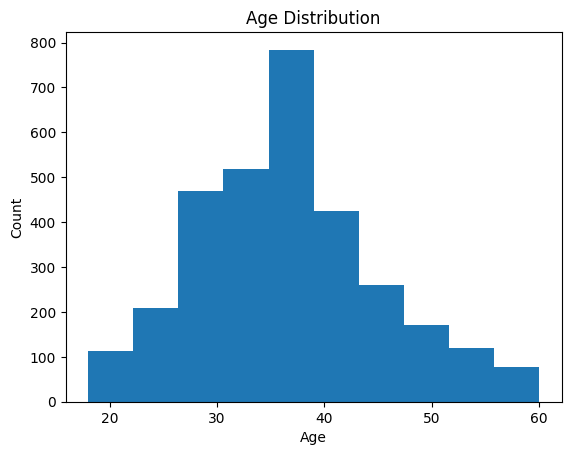

In [59]:

plt.hist(df_clean["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

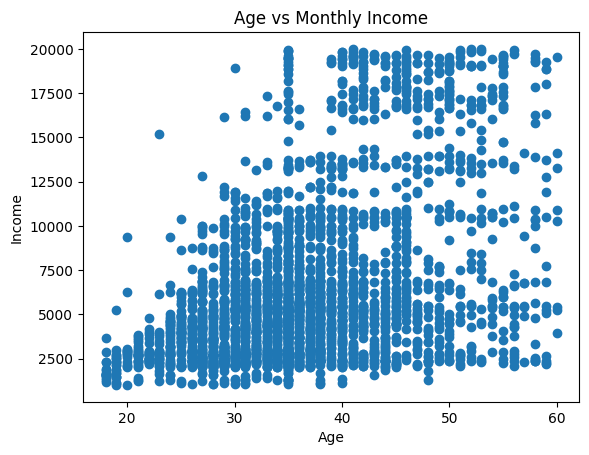

In [60]:
plt.scatter(df_clean["Age"], df_clean["MonthlyIncome"])
plt.title("Age vs Monthly Income")
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

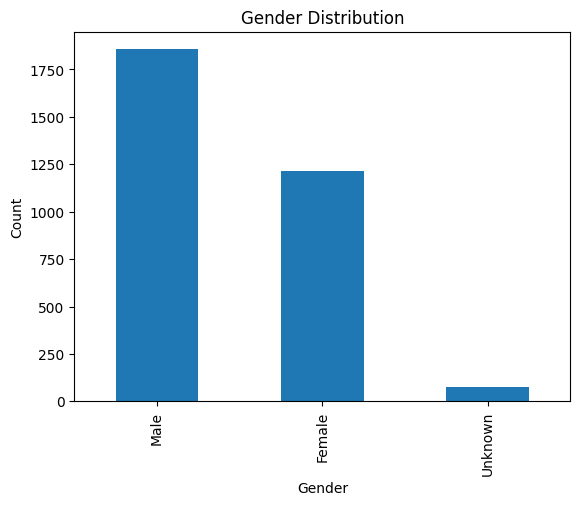

In [61]:
df_clean["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

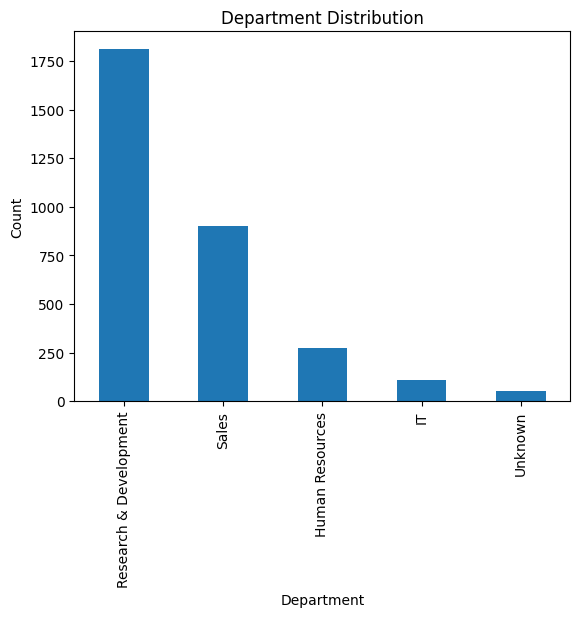

In [62]:
df_clean["Department"].value_counts().plot(kind="bar")
plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

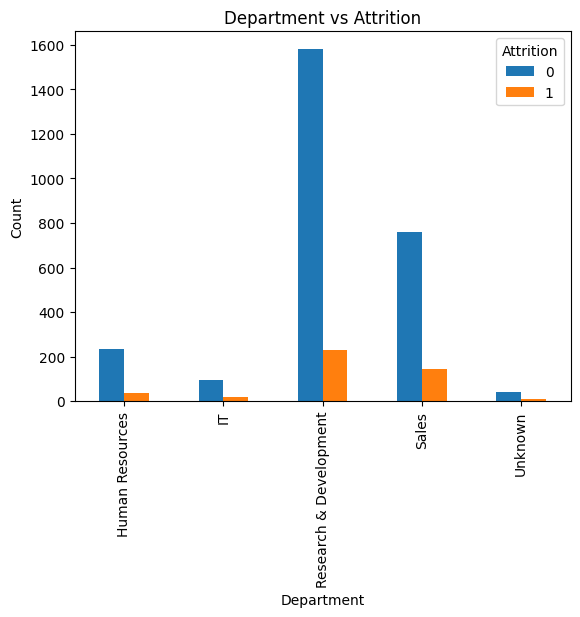

In [63]:
pd.crosstab(df_clean["Department"], df_clean["Attrition"]).plot(kind="bar")

plt.title("Department vs Attrition")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

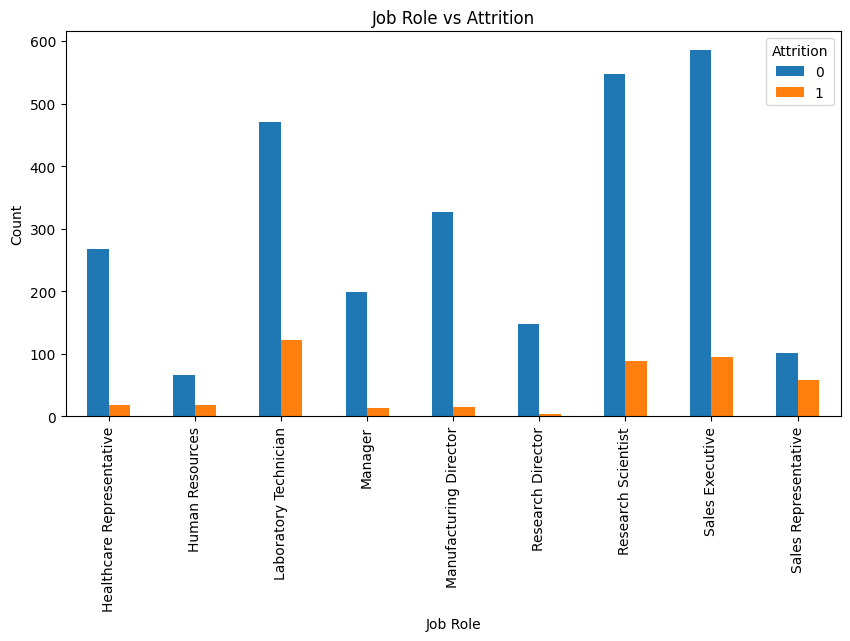

In [64]:
pd.crosstab(df_clean["JobRole"], df_clean["Attrition"]).plot(kind="bar", figsize=(10,5))

plt.title("Job Role vs Attrition")
plt.xlabel("Job Role")
plt.ylabel("Count")
plt.show()

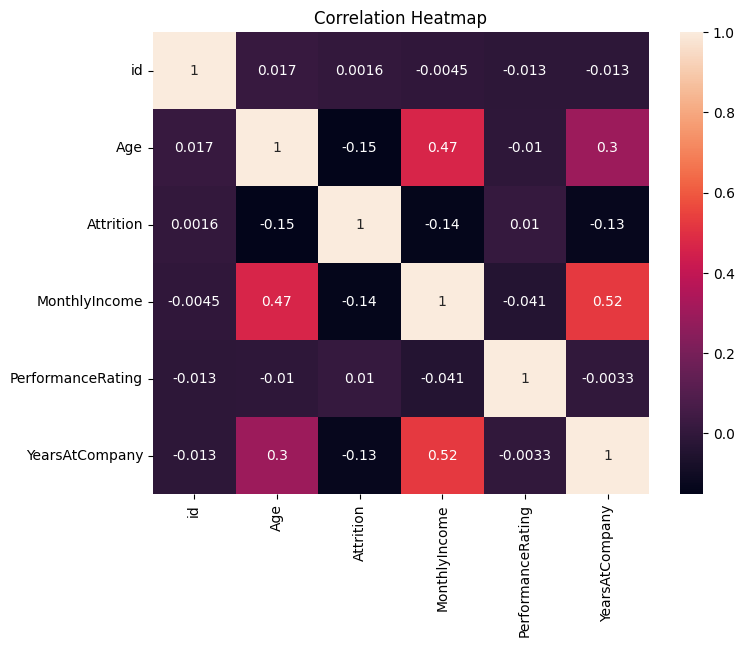

In [65]:
num_df = df_clean.select_dtypes(include=["int64","float64"])

# correlation matrix
corr = num_df.corr()

# heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")
plt.show()

## 📊 Outlier Detection (Boxplot)
# 📈 Identifies extreme values in Monthly Income → helps detect anomalies and unusual salary patterns

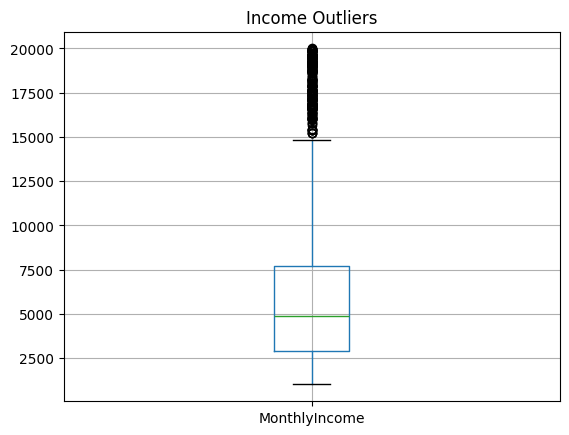

In [66]:
df_clean.boxplot(column="MonthlyIncome")
plt.title("Income Outliers")
plt.show()

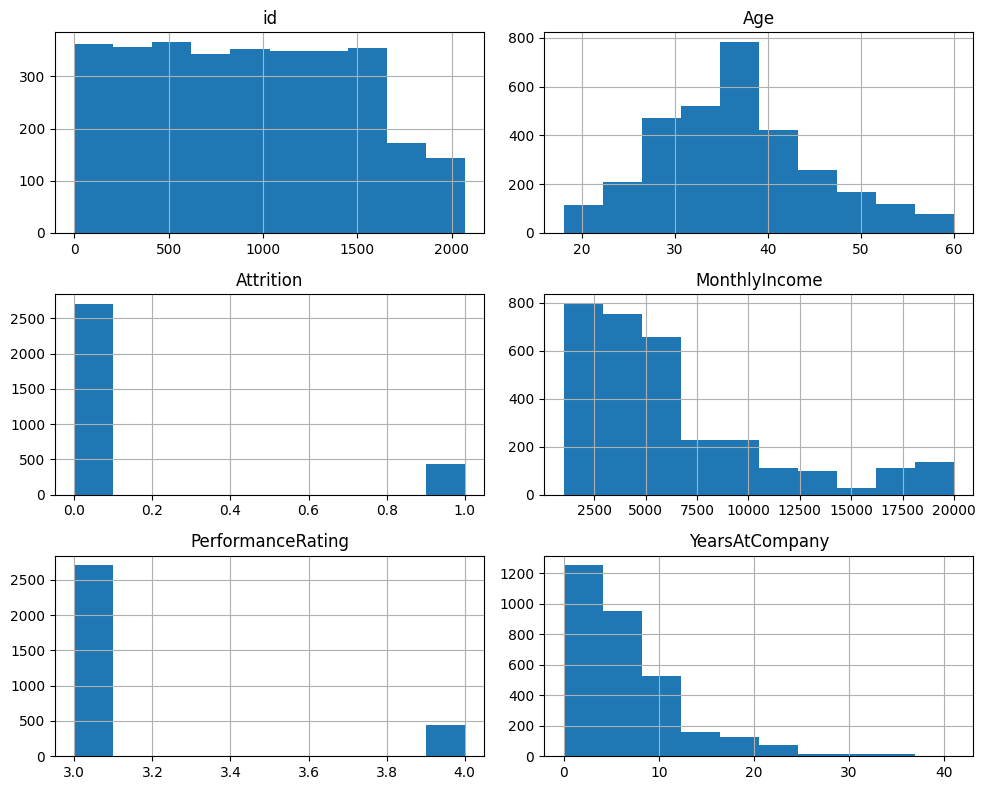

In [67]:
num_cols = df_clean.select_dtypes(include=["int64","float64"]).columns

df_clean[num_cols].hist(figsize=(10,8))
plt.tight_layout()
plt.show()

## 🧹 Outlier Treatment (IQR Method)


# 📊 Calculated IQR (Q1, Q3) → identified lower & upper bounds for normal range  
# 🔄 Applied capping (clip) on Monthly Income → controlled extreme values without removing data  
# ✅ Ensured balanced distribution → improved data quality for accurate analysis

In [93]:
Q1 = df_clean["MonthlyIncome"].quantile(0.25)
Q3 = df_clean["MonthlyIncome"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Only capping (no row deletion)
df_clean["MonthlyIncome"] = df_clean["MonthlyIncome"].clip(lower, upper)

In [94]:
df_clean["MonthlyIncome"] = df_clean["MonthlyIncome"].clip(lower, upper)

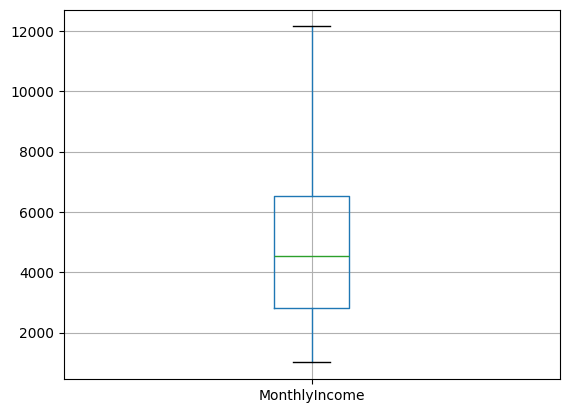

In [95]:
df_clean.boxplot(column="MonthlyIncome")
plt.show()

## 📊 Business Insights & KPI Analysis

# 📈 Calculated key metrics (Attrition %, Avg Income, Avg Experience) → evaluates overall workforce trends  
# 📊 Department-wise Attrition (%) → identifies high-risk departments for employee turnover

In [91]:
# 1. Attrition Rate (%)
attrition_rate = (df_clean["Attrition"].sum() / len(df_clean)) * 100
print("Attrition Rate:", round(attrition_rate, 2), "%")


# 2. Average Monthly Income
avg_income = df_clean["MonthlyIncome"].mean()
print("Average Monthly Income:", round(avg_income, 2))


# 3. Average Years at Company
avg_exp = df_clean["YearsAtCompany"].mean()
print("Average Years at Company:", round(avg_exp, 2))


# 4. Department-wise Attrition
dept_attrition = df_clean.groupby("Department")["Attrition"].mean() * 100
print("Department-wise Attrition (%):")
print(dept_attrition)

Attrition Rate: 14.71 %
Average Monthly Income: 5232.39
Average Years at Company: 6.19
Department-wise Attrition (%):
Department
Human Resources           14.979757
IT                        16.504854
Research & Development    13.500305
Sales                     16.467780
Unknown                   19.607843
Name: Attrition, dtype: float64


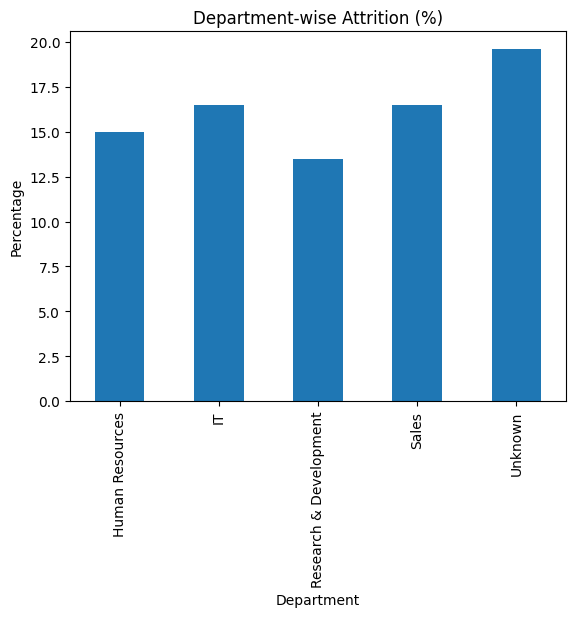

In [92]:
dept_attrition.plot(kind="bar")
plt.title("Department-wise Attrition (%)")
plt.ylabel("Percentage")
plt.show()

In [71]:
df_clean.to_csv("cleaned_data.csv", index=False)

In [72]:
df_clean.head()

,id,Age,Department,JobRole,Gender,Attrition,MonthlyIncome,PerformanceRating,YearsAtCompany
0,0,35,Human Resources,Laboratory Technician,Male,0,2596,3,10
1,1,35,Sales,Sales Representative,Unknown,0,2899,3,4
2,2,32,Sales,Sales Executive,Male,0,4627,3,3
3,3,38,IT,Healthcare Representative,Female,0,5347,3,6
5,5,27,Research & Development,Manufacturing Director,Female,0,4197,3,1


# 🤖 Machine Learning Model (Logistic Regression)

## 📊 Data Preparation
Converted categorical variables into numeric using encoding → enabled model to process data  
Separated features (X) and target (Attrition) → defined prediction goal  

## 🔀 Train-Test Split
Split data into training and testing sets → ensured unbiased model evaluation  

## ⚙️ Model Training
Applied Logistic Regression → used for binary classification (Attrition: Yes/No)  
Handled class imbalance using class_weight → improved prediction fairness  

## 📈 Model Evaluation
Calculated Accuracy → measures overall correct predictions  
Generated Classification Report → shows precision, recall, and F1-score for detailed performance  

## 🔍 Confusion Matrix Analysis
Visualized prediction results → compares actual vs predicted values  
Helps identify:
- True Positives (correct attrition prediction)  
- True Negatives (correct non-attrition prediction)  
- False Positives & False Negatives → model errors  

## ✅ Conclusion
Model provides a baseline for predicting employee attrition → useful for identifying at-risk employees and supporting HR decision-making

In [73]:
df_model = pd.get_dummies(df_clean, drop_first=True)

In [74]:
X = df_model.drop("Attrition", axis=1)
y = df_model["Attrition"]

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [86]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

C:\Users\Sonu Dholpuriya\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [87]:
y_pred = model.predict(X_test)

In [88]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6163194444444444


In [89]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.60      0.73       492
           1       0.23      0.71      0.35        84

    accuracy                           0.62       576
   macro avg       0.58      0.66      0.54       576
weighted avg       0.82      0.62      0.67       576



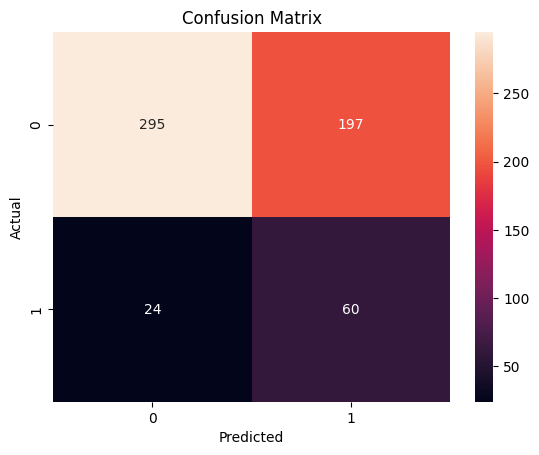

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## ✅ Final Project Conclusion

 📊 The analysis successfully identified key drivers of employee attrition such as income, experience, and department trends → giving clear business insights  

 🧹 Data cleaning (handling nulls, standardizing categories, outlier treatment) significantly improved data quality → ensuring reliable analysis  

 📈 Visualizations revealed important patterns like income distribution, age trends, and department-wise attrition → helping understand employee behavior  

 🤖 The Logistic Regression model provided a baseline prediction for attrition → with moderate accuracy, highlighting scope for improvement  

 🎯 Overall, the project demonstrates an end-to-end data analytics workflow → from raw data processing to insight generation and predictive modeling for HR decision-making